**Students:** Darnell Price, Amira Nasser
**Section:** A
**Date:** May 3, 2026
**Responsibilities:** We shared the work and both presented.

In [1]:
import pandas as pd, matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('mdc_restaurant_inspections_2025.csv')
print(df.shape)

(5179, 8)


In [5]:
df.isna().sum()

inspection_id     0
restaurant_name   0
zip_code          0
inspection_date   0
cuisine          12
score            53
violations        0
result            0
dtype: int64

`score` is what the whole project measures, so the 53 inspections without a score cannot be imputed honestly. We dropped them. Missing `cuisine` values were kept and labeled 'Unknown' so we do not lose inspections for Q2 and Q3.

In [4]:
df = df.dropna(subset=['score'])
df['cuisine'] = df['cuisine'].fillna('Unknown')
print(len(df))

5126


In [3]:
df['inspection_date'] = pd.to_datetime(df['inspection_date'])
df['score'] = pd.to_numeric(df['score'])
df['violations'] = pd.to_numeric(df['violations'])
df['zip_code'] = df['zip_code'].astype(str).str.zfill(5)
print(df.dtypes)

inspection_id                int64
restaurant_name              object
zip_code                     object
inspection_date      datetime64[ns]
cuisine                      object
score                       float64
violations                    int64
result                       object


ZIP codes were stored as numbers, which drops leading zeros and breaks grouping, so we converted them to 5-character strings. Dates became real dates so Q3 can group by month.

In [6]:
df = df.drop_duplicates(subset='inspection_id')
print(len(df))

5113


After removing 13 duplicate inspection ids, **5,113** inspections remain.

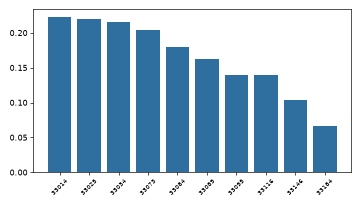

In [7]:
fail_rate = df.assign(fail=df['result'] == 'Fail').groupby('zip_code')['fail'].mean()
top10 = fail_rate.sort_values(ascending=False).head(10)
top10.plot(kind='bar')
plt.show()

The chart shows the results.